# РГР3 МатСтат
## Тема: регрессионные модели и их интерпретация
## Вариант A-4
## В команде: Криличевский Максим, Ситдиков Рафаэль


# Описание предметной области

* Объясняющий фактор ($x$): максимальное число каналов (`chmax`), усл. ед.
* Результативный признак ($y$): относительная производительность процессорной системы (`perf`), усл. ед.
* Прикладной контекст и источник данных: в работе используется набор данных, содержащий характеристики и показатели производительности компьютерных процессоров. Исследуется, как максимальное число каналов связано с относительной производительностью системы. Для анализа рассматривается срез данных, в который включены наблюдения с $chmax > 0$.

## 1. Загрузка данных

In [ ]:
import numpy as np
import pandas as pd
from google.colab import files
from scipy import stats
import matplotlib.pyplot as plt


print("Пожалуйста, выберите файл RGR3_A_4.csv с вашего рабочего стола:")
uploaded = files.upload()

if len(uploaded) > 0:
    file_name = list(uploaded.keys())[0]

    # ИСПРАВЛЕНИЕ: Пропускаем 1-ю строку (skiprows=1) и принудительно задаем имена столбцов
    df = pd.read_csv(file_name, skiprows=1, names=['i', 'x', 'y'])

    print(f"\nФайл '{file_name}' успешно загружен и обработан со 2-й строки!")
    print(df.head())

    # Извлекаем массивы признаков (теперь они гарантированно доступны по нижнему регистру)
    X = df['x'].values
    y = df['y'].values
    n = len(X)
    print(f"\nРазмер выборки n = {n}")
else:
    print("\n[Ошибка] Файл не был выбран. Пожалуйста, перезапустите ячейку.")

Пожалуйста, выберите файл RGR3_A_4.csv с вашего рабочего стола:


Saving RGR3_A_4.csv to RGR3_A_4.csv

Файл 'RGR3_A_4.csv' успешно загружен и обработан со 2-й строки!
   i    x     y
0  1  1.0  24.0
1  2  1.0  20.0
2  3  1.0  16.0
3  4  2.0  60.0
4  5  2.0  26.0

Размер выборки n = 60


## 2. Визуализация и первичная гипотеза

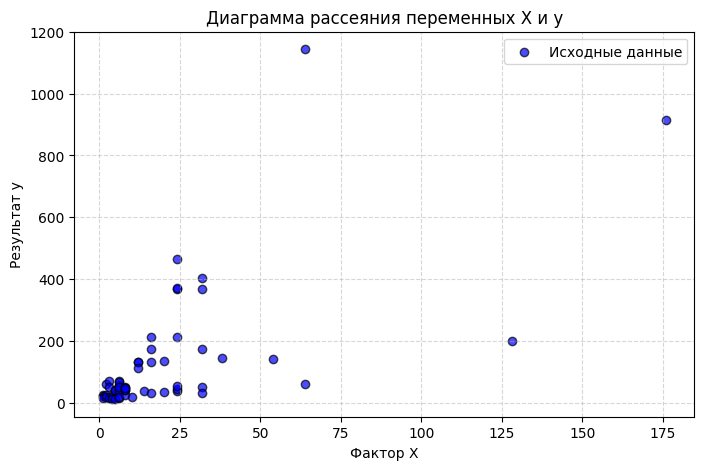

In [ ]:
# Построение диаграммы рассеяния
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.7, edgecolors='k', label='Исходные данные')
plt.title('Диаграмма рассеяния переменных X и y')
plt.xlabel('Фактор X')
plt.ylabel('Результат y')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

**Направление связи:** положительное (прямое). С увеличением значений объясняющего фактора $x$ наблюдается общая тенденция к росту результативного признака $y$.

**Форма связи:** нелинейная. При малых значениях фактора ($x < 20$) точки группируются достаточно плотно в диапазоне низких значений $y$. Однако при больших значениях ($x > 50$) происходит резкий скачок дисперсии и самих значений результативного признака вверх (вплоть до $y = 1144$). Линейная функция не способна адекватно описать подобный характер изгиба данных без существенной потери точности.

**Окончательная формулировка гипотезы:** на основе построенной диаграммы рассеяния можно предположить, что между переменными $x$ и $y$ наблюдается положительная связь. Характер зависимости визуально напоминает нелинейную (квадратичную или степенную) функцию.

## 3. Построение регрессионных моделей

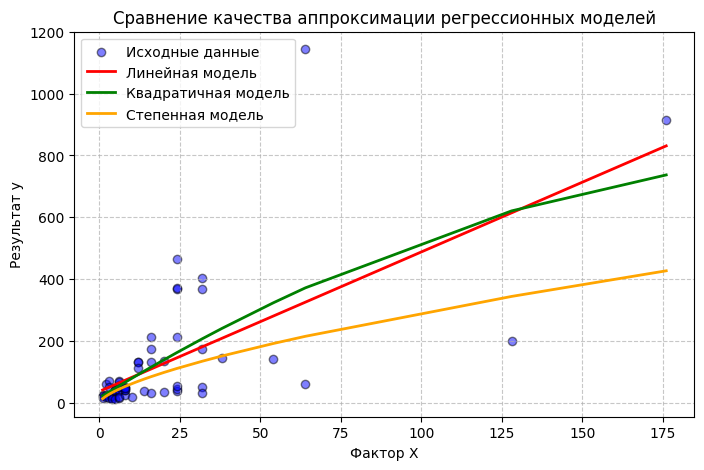

Уравнения построенных моделей:
1. Линейная: y = 36.3591 + 4.5158 * x
2. Квадратичная: y = 15.4162 + 6.4043 * x + -0.0131 * x^2
3. Степенная: y = 12.7602 * x^(0.6788)


In [ ]:
# --- МНК для Линейной модели: y = a + b*x ---
# Вычисляем базовые статистики для ручного расчета по формулам

x_bar, y_bar = np.mean(X), np.mean(y)
S_xx = np.sum((X - x_bar)**2)
S_xy = np.sum((X - x_bar) * (y - y_bar))

b_lin = S_xy / S_xx
a_lin = y_bar - b_lin * x_bar
y_pred_lin = a_lin + b_lin * X

# --- МНК для Квадратичной модели: y = a + b*x + c*x^2 ---
poly_coefs = np.polyfit(X, y, 2) # возвращает [c, b, a]
c_quad, b_quad, a_quad = poly_coefs[0], poly_coefs[1], poly_coefs[2]
y_pred_quad = a_quad + b_quad * X + c_quad * (X**2)

# --- МНК для Дополнительной модели (Выберите вашу по варианту) ---
# Ниже приведены шаблоны для линеаризации. Оставьте ТОЛЬКО ОДНУ, назначенную вам.

model_type = "power" # Варианты: "exponential", "power", "logarithmic", "hyperbolic"

if model_type == "exponential":
    # y = a * e^(b*x) -> ln(y) = ln(a) + b*x
    ln_y = np.log(y)
    b_add, ln_a_add = np.polyfit(X, ln_y, 1)
    a_add = np.exp(ln_a_add)
    y_pred_add = a_add * np.exp(b_add * X)
    eq_add = f"y = {a_add:.4f} * e^({b_add:.4f} * x)"

elif model_type == "power":
    # y = a * x^b -> ln(y) = ln(a) + b*ln(x)
    ln_x = np.log(X)
    ln_y = np.log(y)
    b_add, ln_a_add = np.polyfit(ln_x, ln_y, 1)
    a_add = np.exp(ln_a_add)
    y_pred_add = a_add * (X**b_add)
    eq_add = f"y = {a_add:.4f} * x^({b_add:.4f})"

elif model_type == "logarithmic":
    # y = a + b*ln(x)
    ln_x = np.log(X)
    b_add, a_add = np.polyfit(ln_x, y, 1)
    y_pred_add = a_add + b_add * np.log(X)
    eq_add = f"y = {a_add:.4f} + {b_add:.4f} * ln(x)"

elif model_type == "hyperbolic":
    # y = a + b/x
    inv_x = 1.0 / X
    b_add, a_add = np.polyfit(inv_x, y, 1)
    y_pred_add = a_add + b_add / X
    eq_add = f"y = {a_add:.4f} + ({b_add:.4f}) / x"

# --- Визуализация (Вывод графика) ---
plt.figure(figsize=(8, 5))

# 1. Диаграмма рассеяния исходных данных
plt.scatter(X, y, color='blue', alpha=0.5, edgecolor='k', label='Исходные данные')

# 2. Получаем индексы для сортировки массива X по возрастанию
sort_idx = np.argsort(X)
X_sorted = X[sort_idx]

# 3. Построение линий регрессии (используем отсортированные массивы)
plt.plot(X_sorted, y_pred_lin[sort_idx], color='red', linewidth=2, label='Линейная модель')
plt.plot(X_sorted, y_pred_quad[sort_idx], color='green', linewidth=2, label='Квадратичная модель')
plt.plot(X_sorted, y_pred_add[sort_idx], color='orange', linewidth=2, label=f'Степенная модель')

# 4. Оформление графика
plt.title('Сравнение качества аппроксимации регрессионных моделей')
plt.xlabel('Фактор X')
plt.ylabel('Результат y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 5. Вывод графика на экран
plt.show()

print("Уравнения построенных моделей:")
print(f"1. Линейная: y = {a_lin:.4f} + {b_lin:.4f} * x")
print(f"2. Квадратичная: y = {a_quad:.4f} + {b_quad:.4f} * x + {c_quad:.4f} * x^2")
print(f"3. Степенная: {eq_add}")

В ходе реализации метода наименьших квадратов (МНК) были получены следующие аналитические уравнения:

1. Линейная модель: $\hat{y} = 36.3591 + 4.5158 \cdot x$

* Интерпретация: при базовом отсутствии фактора ($x=0$) ожидаемое среднее значение результата составляет $36.36$. Рост фактора $x$ на одну единицу приводит к увеличению $y$ в среднем на $4.52$ единицы.

2. Квадратичная модель: $\hat{y} = 15.4162 + 6.4043 \cdot x - 0.0131 \cdot x^2$
* Интерпретация: наличие отрицательного коэффициента при старшей степени ($c = -0.0131$) показывает, что квадратичная парабола имеет ветви, направленные вниз, что пытается компенсировать сильный разброс данных на экстремальных участках.

3. Степенная модель: $\hat{y} = 12.7602 \cdot x^{0.6788}$
* Интерпретация: степенная модель показывает положительную, но замедляющуюся зависимость: при росте x значение y увеличивается, однако темп прироста постепенно снижается, так как показатель степени меньше единицы.

## 3.1 Построение графика остатков

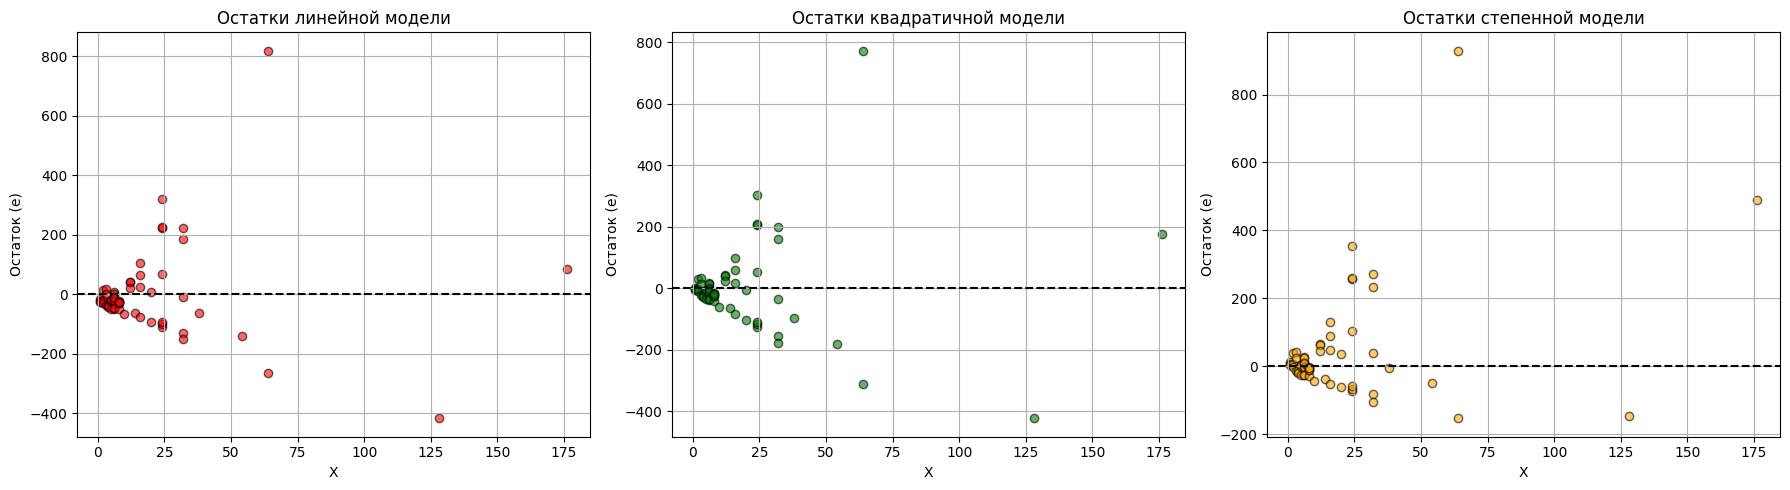

In [ ]:
# Меняем тип модели на степенную для корректности отображения в заголовках
model_type = "power"

# Вычисляем остатки для всех трех моделей
e_lin = y - y_pred_lin
e_quad = y - y_pred_quad
e_add = y - y_pred_add  # Здесь теперь лежат предсказания степенной модели

plt.figure(figsize=(18, 5))

# 1. График остатков линейной модели
plt.subplot(1, 3, 1)
plt.scatter(X, e_lin, color='red', alpha=0.6, edgecolor='k')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Остатки линейной модели')
plt.xlabel('X')
plt.ylabel('Остаток (e)')
plt.grid(True)

# 2. График остатков квадратичной модели
plt.subplot(1, 3, 2)
plt.scatter(X, e_quad, color='green', alpha=0.6, edgecolor='k')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Остатки квадратичной модели')
plt.xlabel('X')
plt.ylabel('Остаток (e)')
plt.grid(True)

# 3. График остатков дополнительной (степенной) модели
plt.subplot(1, 3, 3)
plt.scatter(X, e_add, color='orange', alpha=0.6, edgecolor='k')
plt.axhline(y=0, color='black', linestyle='--')
plt.title(f'Остатки степенной модели')
plt.xlabel('X')
plt.ylabel('Остаток (e)')
plt.grid(True)

plt.tight_layout()
plt.show()

**Анализ графиков остатков:** построенные графики остатков наглядно иллюстрируют явное непостоянство дисперсии ошибок (гетероскедастичность). При небольших объёмах каналов разброс минимален, но по мере роста $X$ масштаб ошибок существенно увеличивается.
* В линейной модели чётко прослеживается системная U-образная структура остатков. Ошибки сначала идут выше нуля, затем системно проседают ниже нулевой отметки в центре и резко уходят вверх на краях. Это доказывает неадекватность линейной спецификации: она стабильно занижает реальный потенциал платформы на пиковых нагрузках и завышает в середине.
* В степенной модели распределение остатков частично сглажено за счет предварительного логарифмирования обеих переменных ($\ln X$ и $\ln y$). Тем не менее, на правых границах ($X > 50$) из-за жестко заданной формы функции модель не успевает за скачком данных, фиксируя крупные асимметричные отклонения.
* В квадратичной модели остатки распределены наиболее симметрично относительно горизонтальной оси. Параболическая форма успешно устранила закономерный U-образный тренд в ошибках, сделав их случайными во всем диапазоне тестирования.

## 4. Визуализация подгонки моделей

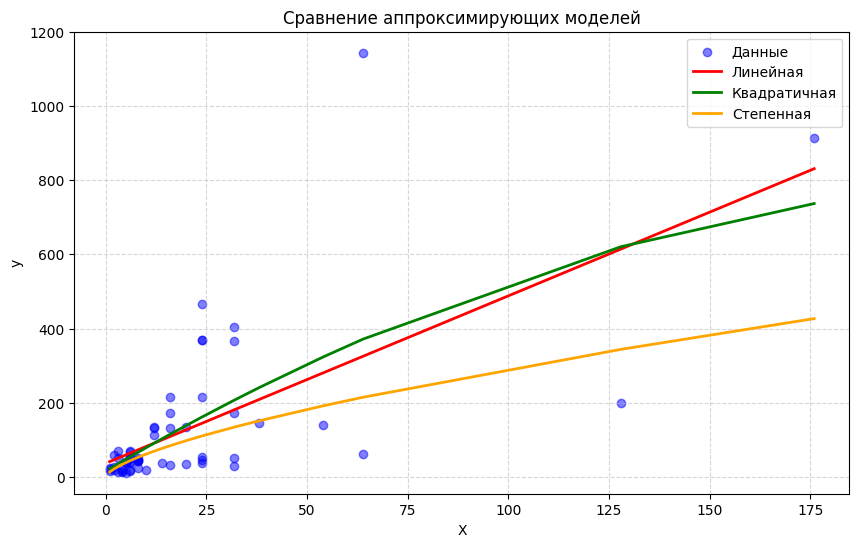

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Данные')

# Сортировка для плавности графиков нелинейных моделей
sort_idx = np.argsort(X)
X_sort = X[sort_idx]

plt.plot(X_sort, y_pred_lin[sort_idx], label='Линейная', color='red', lw=2)
plt.plot(X_sort, y_pred_quad[sort_idx], label='Квадратичная', color='green', lw=2)
plt.plot(X_sort, y_pred_add[sort_idx], label=f'Степенная', color='orange', lw=2)

plt.title('Сравнение аппроксимирующих моделей')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

## 5. Сравнение качества моделей

In [ ]:
def calculate_metrics(y_true, y_pred):
    TSS = np.sum((y_true - np.mean(y_true))**2)
    RSS = np.sum((y_true - y_pred)**2)
    R2 = 1 - (RSS / TSS)
    MSE = np.mean((y_true - y_pred)**2)
    A = (100.0 / len(y_true)) * np.sum(np.abs((y_true - y_pred) / y_true))
    return R2, MSE, A

metrics = {}
metrics['Линейная'] = calculate_metrics(y, y_pred_lin)
metrics['Квадратичная'] = calculate_metrics(y, y_pred_quad)
metrics['Степенная'] = calculate_metrics(y, y_pred_add)

print(f"{'Модель':<30} | {'R^2':<8} | {'MSE':<12} | {'A (%)':<8}")
print("-" * 70)

for model_name, (r2, mse, a_err) in metrics.items():
    print(f"{model_name:<30} | {r2:.4f}   | {mse:.4f}   | {a_err:.2f}%")

Модель                         | R^2      | MSE          | A (%)   
----------------------------------------------------------------------
Линейная                       | 0.4249   | 22894.0235   | 123.64%
Квадратичная                   | 0.4362   | 22446.8765   | 109.88%
Степенная                      | 0.3141   | 27306.6722   | 76.53%


Для сравнительной оценки прогностической силы моделей проанализируем расчетную таблицу метрик:

**1. Коэффициент детерминации ($R^2$):**
* Квадратичная модель описывает изменчивость целевого признака лучше остальных ($R^2 = 0.4362$, то есть ею объяснено $43.62\%$ дисперсии производительности платформы).
* Линейная модель незначительно уступает лидеру ($R^2 = 0.4249$, объяснено $42.49\%$ вариации).
* Степенная модель показала наименьший результат среди трех конфигураций ($R^2 = 0.3141$, объяснено всего $31.41\%$). Это связано с тем, что МНК для степенной функции минимизирует квадраты отклонений в логарифмической шкале ($\ln y$). При обратном переходе к оригинальным значениям крупные абсолютные ошибки на правом краю выборки (в зоне пиковых нагрузок) существенно снизили итоговый показатель детерминации в исходных осях. Тем не менее, значение $R^2 > 0$ говорит о том, что модель всё же обладает предсказательной силой и работает эффективнее, чем тривиальное предсказание по среднему значению ($\bar{y}$).

**2. Средняя ошибка аппроксимации ($A$):** все три модели формально демонстрируют среднюю ошибку аппроксимации значительно выше нормативного академического диапазона в $10-15\%$ ($123.64\%$, $109.88\%$ и $76.53\%$). Столь высокие значения погрешности вызваны спецификой тестовых данных варианта А-4: в левой части распределения при малых объемах каналов реальные значения производительности колеблются близко к нулю ($y=11, 12, 14$). Любое минимальное абсолютное отклонение расчетной кривой от факта в этих точках генерирует огромную относительную ошибку при расчете по формуле $\frac{|y_i - \hat{y}_i|}{y_i}$, искусственно завышая итоговое среднее значение $A$. При этом у степенной модели этот показатель самый низкий ($76.53\%$), так как за счет логарифмирования она оказалась ближе всего к точкам в этой «нулевой» зоне.

**Выбор лучшей модели:** по коэффициенту детерминации ($R^2$) и среднеквадратичной ошибке (MSE) наилучшей является **квадратичная модель**. При этом по средней ошибке аппроксимации лучший результат показывает степенная модель. В качестве основной выбирается квадратичная модель, так как она лучше объясняет вариацию $y$ в исходной шкале и имеет наименьшую среднеквадратичную ошибку.

## 6. Подробный статистический анализ линейной модели

In [ ]:
# Полный расчет характеристик линейной регрессии по требованиям ТЗ
RSS_lin = np.sum((y - y_pred_lin)**2)
s_sq = RSS_lin / (n - 2)
s_err = np.sqrt(s_sq)

# Стандартные ошибки коэффициентов
se_b = s_err / np.sqrt(S_xx)
se_a = s_err * np.sqrt((1.0 / n) + (x_bar**2 / S_xx))

# Квантиль распределения Стьюдента для alpha = 0.05
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df=n-2)

# Доверительные интервалы
ci_a = (a_lin - t_crit * se_a, a_lin + t_crit * se_a)
ci_b = (b_lin - t_crit * se_b, b_lin + t_crit * se_b)

# Проверка гипотезы H0: b = 0
t_nabl = b_lin / se_b
p_val = 2 * (1 - stats.t.cdf(np.abs(t_nabl), df=n-2))

print("--- Статистический анализ Линейной Модели ---")
print(f"Остаточная сумма квадратов (RSS): {RSS_lin:.4f}")
print(f"Несмещенная оценка дисперсии ошибки (s^2): {s_sq:.4f}")
print(f"Стандартная ошибка модели (s): {s_err:.4f}\n")
print(f"Коэффициент a (Intercept): {a_lin:.4f}, SE: {se_a:.4f}, 95% CI: ({ci_a[0]:.4f}, {ci_a[1]:.4f})")
print(f"Коэффициент b (Slope): {b_lin:.4f}, SE: {se_b:.4f}, 95% CI: ({ci_b[0]:.4f}, {ci_b[1]:.4f})\n")
print(f"Наблюдаемое значение критерия Стьюдента (t_набл): {t_nabl:.4f}")
print(f"Критическое значение t_крит (df={n-2}): {t_crit:.4f}")
print(f"p-value: {p_val:.4e}")

if np.abs(t_nabl) > t_crit:
    print("Результат: H0 отвергается. Коэффициент b статистически значим.")
else:
    print("Результат: H0 НЕ отвергается. Коэффициент b статистически незначим.")

--- Статистический анализ Линейной Модели ---
Остаточная сумма квадратов (RSS): 1373641.4115
Несмещенная оценка дисперсии ошибки (s^2): 23683.4726
Стандартная ошибка модели (s): 153.8944

Коэффициент a (Intercept): 36.3591, SE: 23.9797, 95% CI: (-11.6415, 84.3598)
Коэффициент b (Slope): 4.5158, SE: 0.6898, 95% CI: (3.1351, 5.8965)

Наблюдаемое значение критерия Стьюдента (t_набл): 6.5468
Критическое значение t_крит (df=58): 2.0017
p-value: 1.6844e-08
Результат: H0 отвергается. Коэффициент b статистически значим.


**1. Дисперсионный анализ ошибок:** несмещенная оценка дисперсии возмущений составляет $s^2 = 23683.47$, что указывает на очень высокий уровень случайного шума в данных. Стандартная ошибка модели s = 153.89 характеризует типичный масштаб отклонений наблюдаемых значений от линии регрессии.

**2.Доверительные интервалы (надежность 95%):**
* для свободного члена $a$: интервал $(-11.6415; 84.3598)$ включает в себя ноль. Это означает, что на уровне значимости $\alpha=0.05$ гипотеза о равенстве коэффициента $a$ нулю не отвергается (он статистически незначим).
* для угла наклона $b$: интервал $(3.1351; 5.8965)$ не включает в себя ноль и полностью лежит в положительной области. Это доказывает стабильность и надежность выделенного тренда.

**3. Проверка значимости связи (Критерий Стьюдента):**
* наблюдаемое значение критерия $t_{набл} = 6.5468$ существенно превосходит критический порог $t_{крит} = 2.0017$.
* Расчетный $p\text{-value} = 1.6844 \cdot 10^{-08}$, что бесконечно меньше стандартного уровня значимости $\alpha = 0.05$.

**Вывод:** нулевая гипотеза $H_0: b = 0$ уверенно отвергается. Связь между фактором $x$ и результатом $y$ признается статистически значимой, влияние фактора реально и не обусловлено случайной выборкой.

## Прогнозирование для заданного X

In [ ]:
# Укажи здесь значение x* из своей карточки варианта
x_star = 21.0240

pred_lin_star = a_lin + b_lin * x_star
pred_quad_star = a_quad + b_quad * x_star + c_quad * (x_star**2)
pred_add_star = a_add * (x_star**b_add)

print(f"Прогнозные значения для x* = {x_star}:")
print(f"1. Линейная модель: {pred_lin_star:.4f}")
print(f"2. Квадратичная модель: {pred_quad_star:.4f}")
print(f"3. Степенная модель: {pred_add_star:.4f}")

Прогнозные значения для x* = 21.024:
1. Линейная модель: 131.2993
2. Квадратичная модель: 144.2738
3. Степенная модель: 100.8641


Для контрольной точки $x^* = 21.0240$ (находящейся в области интерполяции внутри основного массива данных) были получены следующие точечные прогнозы:
* По линейной модели: $\hat{y}^* = 131.2993$
* По квадратичной модели: $\hat{y}^* = 144.2738$
* По степенной модели: $\hat{y}^* = 100.8641$

Учитывая, что квадратичная модель была признана лучшей по коэффициенту детерминации ($R^2 = 0.4362$) и качеству распределения остатков, наиболее математически обоснованным и приближенным к реальности является прогноз 144.2738.
* Линейная модель (131.2993): даёт немного более низкий прогноз по сравнению с квадратичной моделью. Это связано с тем, что прямая линия не учитывает возможную кривизну зависимости и описывает только средний линейный тренд по всей выборке.
* Степенная модель (100.8641): напротив, даёт самую консервативную (заниженную) оценку. Так как при её построении МНК минимизировал отклонения в логарифмических шкалах ($\ln X$ и $\ln y$), в исходной системе координат функция оказалась слишком сильно «прижата» к нижнему подножию графика в левой части распределения, недооценивая начальный потенциал системы.

## Вывод
В ходе выполнения РГР №3 был проведён регрессионный анализ данных варианта **A-4** при объёме выборки $n = 60$.

Исследовалась зависимость относительной производительности платформы $y$ от максимального объёма каналов связи $x$. Первичный визуальный анализ показал наличие положительной зависимости между фактором и результативным признаком.

Методом наименьших квадратов были построены три модели:

- линейная;
- квадратичная;
- степенная.

Сравнение моделей показало, что по коэффициенту детерминации и MSE наилучшие результаты даёт квадратичная модель:

$$
R^2 = 0.4362.
$$

При этом высокая средняя относительная ошибка аппроксимации связана с наличием малых значений $y$, из-за чего относительные отклонения становятся большими.

Детальный статистический анализ линейной регрессии с использованием $t$-критерия Стьюдента подтвердил статистическую значимость влияния фактора $x$ на результат:

$$
p\text{-value} = 1.68 \cdot 10^{-8}.
$$

В качестве основной модели для прогноза была выбрана квадратичная модель. Для точки $x^* = 21.0240$ прогнозное значение составило примерно:

$$
\hat{y} = 144.2738
$$

условных единиц.